# Poisson (within Generalised Linear Models)

In [4]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy.stats as stats

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence \
import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

In [5]:
df = pd.read_csv('Bikeshare.csv')
df

,season,mnth,day,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,bikers
0,1,Jan,1,0,0,6,0,clear,0.24,0.2879,0.81,0.0000,3,13,16
1,1,Jan,1,1,0,6,0,clear,0.22,0.2727,0.80,0.0000,8,32,40
2,1,Jan,1,2,0,6,0,clear,0.22,0.2727,0.80,0.0000,5,27,32
3,1,Jan,1,3,0,6,0,clear,0.24,0.2879,0.75,0.0000,3,10,13
4,1,Jan,1,4,0,6,0,clear,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8640,1,Dec,365,19,0,6,0,clear,0.42,0.4242,0.54,0.2239,19,73,92
8641,1,Dec,365,20,0,6,0,clear,0.42,0.4242,0.54,0.2239,8,63,71
8642,1,Dec,365,21,0,6,0,clear,0.40,0.4091,0.58,0.1940,2,50,52
8643,1,Dec,365,22,0,6,0,clear,0.38,0.3939,0.62,0.1343,2,36,38


## Underperforming Linear Regression 
### Using StatsModel API

In [8]:
# The formula automatically adds a constant (Intercept) 
# and creates dummies for categorical variables.
model_formula = ols('bikers ~ workingday + temp + C(weathersit) + C(mnth) + C(hr)', 
                    data=df).fit()

print("--- FORMULA METHOD RESULTS ---")
display(model_formula.summary())

--- FORMULA METHOD RESULTS ---


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 bikers   R-squared:                       0.675
Model:                            OLS   Adj. R-squared:                  0.673
Method:                 Least Squares   F-statistic:                     457.3
Date:                Mon, 06 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:15:20   Log-Likelihood:                -49743.
No. Observations:                8645   AIC:                         9.957e+04
Df Residuals:                    8605   BIC:                         9.985e+04
Df Model:                          39                                         
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                          -27.2068      6.715     -4.052      0.000     -40.370     -14.044
C(weathersit)[T.cloudy/misty]      -12.8903      1.964     -6.562      0.000     -16.741      -9.040
C(weathersit)[T.heavy rain/snow]  -109.7446     76.667     -1.431      0.152    -260.031      40.542
C(weathersit)[T.light rain/snow]   -66.4944      2.965    -22.425      0.000     -72.307     -60.682
C(mnth)[T.Aug]                      11.8181      4.698      2.515      0.012       2.609      21.028
C(mnth)[T.Dec]                       5.0328      4.280      1.176      0.240      -3.357      13.423
C(mnth)[T.Feb]                     -34.5797      4.575     -7.558      0.000     -43.548     -25.611
C(mnth)[T.Jan]                     -41.4249      4.972     -8.331      0.000     -51.172     -31.678
C(mnth)[T.July]                      3.8996      5.003      0.779      0.436      -5.907      13.706
C(mnth)[T.June]                     26.3938      4.642      5.686      0.000      17.294      35.493
C(mnth)[T.March]                   -24.8735      4.277     -5.815      0.000     -33.258     -16.489
C(mnth)[T.May]                      31.1322      4.150      7.501      0.000      22.997      39.268
C(mnth)[T.Nov]                      18.8851      4.099      4.607      0.000      10.850      26.920
C(mnth)[T.Oct]                      34.4093      4.006      8.589      0.000      26.556      42.262
C(mnth)[T.Sept]                     25.2534      4.293      5.883      0.000      16.839      33.668
C(hr)[T.1]                         -14.5793      5.699     -2.558      0.011     -25.750      -3.408
C(hr)[T.2]                         -21.5791      5.733     -3.764      0.000     -32.817     -10.341
C(hr)[T.3]                         -31.1408      5.778     -5.389      0.000     -42.468     -19.814
C(hr)[T.4]                         -36.9075      5.802     -6.361      0.000     -48.281     -25.534
C(hr)[T.5]                         -24.1355      5.737     -4.207      0.000     -35.381     -12.890
C(hr)[T.6]                          20.5997      5.704      3.612      0.000       9.419      31.781
C(hr)[T.7]                         120.0931      5.693     21.095      0.000     108.934     131.253
C(hr)[T.8]                         223.6619      5.690     39.310      0.000     212.509     234.815
C(hr)[T.9]                         120.5819      5.693     21.182      0.000     109.423     131.741
C(hr)[T.10]                         83.8013      5.705     14.689      0.000      72.618      94.985
C(hr)[T.11]                        105.4234      5.722     18.424      0.000      94.207     116.640
C(hr)[T.12]                        137.2837      5.740     23.916      0.000     126.032     148.536
C(hr)[T.13]                        136.0359      5.76

### Dummy coding - same intercept as book

In [24]:
df = pd.read_csv('Bikeshare.csv')

In [26]:
formula = 'bikers ~ workingday + temp + C(weathersit) + C(mnth, Sum) + C(hr, Sum)'
model = ols(formula, data=df).fit()
display(model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 bikers   R-squared:                       0.675
Model:                            OLS   Adj. R-squared:                  0.673
Method:                 Least Squares   F-statistic:                     457.3
Date:                Mon, 06 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:42:31   Log-Likelihood:                -49743.
No. Observations:                8645   AIC:                         9.957e+04
Df Residuals:                    8605   BIC:                         9.985e+04
Df Model:                          39                                         
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                           73.5974      5.132     14.340      0.000      63.537      83.658
C(weathersit)[T.cloudy/misty]      -12.8903      1.964     -6.562      0.000     -16.741      -9.040
C(weathersit)[T.heavy rain/snow]  -109.7446     76.667     -1.431      0.152    -260.031      40.542
C(weathersit)[T.light rain/snow]   -66.4944      2.965    -22.425      0.000     -72.307     -60.682
C(mnth, Sum)[S.April]               -4.6622      2.741     -1.701      0.089     -10.034       0.710
C(mnth, Sum)[S.Aug]                  7.1560      3.535      2.024      0.043       0.227      14.085
C(mnth, Sum)[S.Dec]                  0.3706      3.156      0.117      0.907      -5.816       6.558
C(mnth, Sum)[S.Feb]                -39.2419      3.539    -11.088      0.000     -46.179     -32.304
C(mnth, Sum)[S.Jan]                -46.0871      4.085    -11.281      0.000     -54.096     -38.079
C(mnth, Sum)[S.July]                -0.7626      3.908     -0.195      0.845      -8.424       6.899
C(mnth, Sum)[S.June]                21.7317      3.465      6.272      0.000      14.939      28.524
C(mnth, Sum)[S.March]              -29.5357      3.155     -9.361      0.000     -35.721     -23.351
C(mnth, Sum)[S.May]                 26.4700      2.851      9.285      0.000      20.882      32.058
C(mnth, Sum)[S.Nov]                 14.2229      2.860      4.972      0.000       8.616      19.830
C(mnth, Sum)[S.Oct]                 29.7472      2.700     11.019      0.000      24.455      35.039
C(hr, Sum)[S.0]                    -96.1420      3.955    -24.307      0.000    -103.895     -88.389
C(hr, Sum)[S.1]                   -110.7213      3.966    -27.916      0.000    -118.496    -102.947
C(hr, Sum)[S.2]                   -117.7212      4.016    -29.310      0.000    -125.594    -109.848
C(hr, Sum)[S.3]                   -127.2828      4.081    -31.191      0.000    -135.282    -119.283
C(hr, Sum)[S.4]                   -133.0495      4.117    -32.319      0.000    -141.119    -124.980
C(hr, Sum)[S.5]                   -120.2775      4.037    -29.794      0.000    -128.191    -112.364
C(hr, Sum)[S.6]                    -75.5424      3.992    -18.925      0.000     -83.367     -67.718
C(hr, Sum)[S.7]                     23.9511      3.969      6.035      0.000      16.172      31.730
C(hr, Sum)[S.8]                    127.5199      3.950     32.284      0.000     119.777     135.263
C(hr, Sum)[S.9]                     24.4399      3.936      6.209      0.000      16.724      32.155
C(hr, Sum)[S.10]                   -12.3407      3.936     -3.135      0.002     -20.056      -4.625
C(hr, Sum)[S.11]                     9.2814      3.945      2.353      0.019       1.549      17.014
C(hr, Sum)[S.12]                    41.1417      3.95

**Why the slopes (temp/workingday) stayed the same**

You noticed that temp was $157.21$ in both your "wrong" version and the book. 

This is a cool property of linear models: Changing the baseline of a categorical variable shifts the Intercept, but it does not change the slopes of the continuous variables. 
The relationship between heat and biking is a physical constant in this data; it doesn't matter if you start counting from Midnight or the daily average, 1 degree of heat still adds the same number of riders.
- Intercept = $-27.20$: You are using Treatment/Dummy coding (comparing everything to `Hour 0`/`Month 1`).
- Intercept = $73.60$: You are using Sum/Deviation coding (comparing everything to the overall average).If you run the code block above with Sum, you'll see that $73.60$ pop up immediately.

## Plotting the Coefficients to study Linear Regression

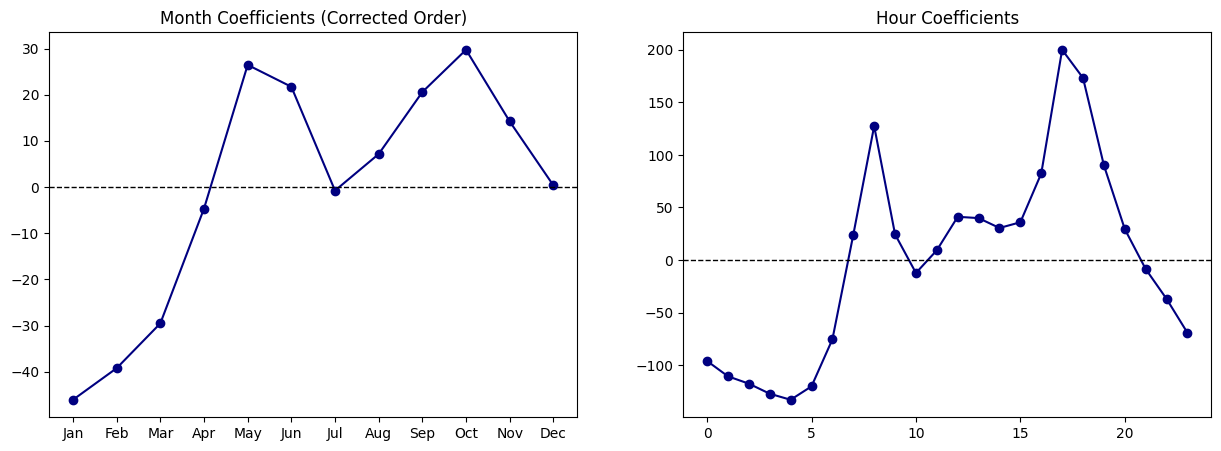

In [30]:
# 1. Grab parameters directly from your model object
# This assumes your model is named 'model'
params = model.params

# 2. Define the exact chronological order and their corresponding keys in your table
month_order = [
    'Jan', 'Feb', 'March', 'April', 'May', 'June', 
    'July', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec'
]

# 3. Build the list of coefficients
month_coefs = []
all_found_coefs = []

for m in month_order:
    key = f"C(mnth, Sum)[S.{m}]"
    if key in params:
        val = params[key]
        month_coefs.append(val)
        all_found_coefs.append(val)
    else:
        # If the month is missing (like Sept), put a placeholder
        month_coefs.append(None)

# 4. Calculate the missing value (September) 
# Sum coding requires all coefficients to sum to 0
missing_val = -sum(all_found_coefs)

# Fill the None (September) with the calculated value
month_coefs = [val if val is not None else missing_val for val in month_coefs]

# 5. Extract Hours (0-22 are in your table, 23 is missing)
hour_coefs = [params[f"C(hr, Sum)[S.{i}]"] for i in range(23)]
hour_coefs.append(-sum(hour_coefs)) # Add Hour 23

# 6. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Left Plot: Months (Using full names for the x-axis to be clear)
months_x = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax1.plot(months_x, month_coefs, marker='o', color='navy', linestyle='-')
ax1.axhline(0, color='black', lw=1, ls='--')
ax1.set_title("Month Coefficients (Corrected Order)")

# Right Plot: Hours
ax2.plot(range(24), hour_coefs, marker='o', color='navy', linestyle='-')
ax2.axhline(0, color='black', lw=1, ls='--')
ax2.set_title("Hour Coefficients")

plt.show()

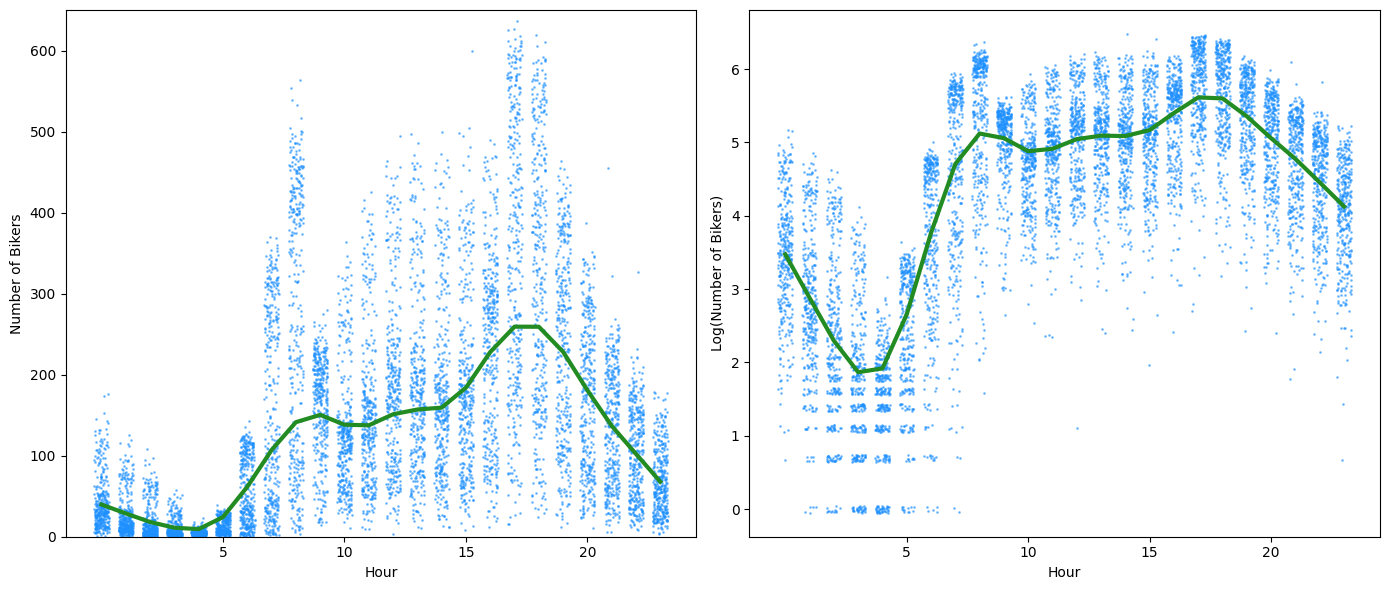

In [31]:
bikeshare = pd.read_csv('Bikeshare.csv')

# 2. Add Jitter
# Without jitter, points at the same hour/count would overlap completely
def add_jitter(series, amount=0.3):
    return series + np.random.uniform(-amount, amount, size=len(series))

bikers_jitter = add_jitter(bikeshare['bikers'], amount=2.0)
hr_jitter = add_jitter(bikeshare['hr'], amount=0.3)
log_bikers_jitter = add_jitter(np.log(bikeshare['bikers']), amount=0.05)

# 3. Setup the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- LEFT PLOT: Number of Bikers ---
ax1.scatter(hr_jitter, bikers_jitter, s=1, alpha=0.5, color='dodgerblue')
# Add Smoothing Spline (Lowess)
lowess_left = sm.nonparametric.lowess(bikeshare['bikers'], bikeshare['hr'], frac=0.2)
ax1.plot(lowess_left[:, 0], lowess_left[:, 1], color='forestgreen', linewidth=3)

ax1.set_xlabel('Hour')
ax1.set_ylabel('Number of Bikers')
ax1.set_xticks([5, 10, 15, 20])
ax1.set_ylim(0, 650)

# --- RIGHT PLOT: Log(Number of Bikers) ---
ax2.scatter(hr_jitter, log_bikers_jitter, s=1, alpha=0.5, color='dodgerblue')
# Add Smoothing Spline (Lowess) for Log scale
lowess_right = sm.nonparametric.lowess(np.log(bikeshare['bikers']), bikeshare['hr'], frac=0.2)
ax2.plot(lowess_right[:, 0], lowess_right[:, 1], color='forestgreen', linewidth=3)

ax2.set_xlabel('Hour')
ax2.set_ylabel('Log(Number of Bikers)')
ax2.set_xticks([5, 10, 15, 20])

plt.tight_layout()
plt.show()

## Annex 1 - Scikit notation (same results)

In [32]:
df = pd.read_csv('Bikeshare.csv')

# 1. Manually create dummy variables for categorical columns
# We drop the first category (e.g., Clear Skies) to avoid the "Dummy Variable Trap"
weather_dummies = pd.get_dummies(df['weathersit'], drop_first=True, prefix='weather')
mnth_dummies = pd.get_dummies(df['mnth'], drop_first=True, prefix='mnth')
hr_dummies = pd.get_dummies(df['hr'], drop_first=True, prefix='hr')

# 2. Combine all predictors into one DataFrame
X = pd.concat([df[['workingday', 'temp']], 
               weather_dummies, mnth_dummies, hr_dummies], axis=1)

# 3. CRITICAL: Manually add the column of 1s for the Intercept
X = sm.add_constant(X)

# 4. Target variable
y = df['bikers']

# 5. Fit the model using OLS (capital letters signify Matrix input)
model_manual = sm.OLS(y, X.astype(float)).fit()

print("--- MANUAL MATRIX METHOD RESULTS ---")
display(model_manual.summary())

--- MANUAL MATRIX METHOD RESULTS ---


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 bikers   R-squared:                       0.675
Model:                            OLS   Adj. R-squared:                  0.673
Method:                 Least Squares   F-statistic:                     457.3
Date:                Mon, 06 Apr 2026   Prob (F-statistic):               0.00
Time:                        14:00:26   Log-Likelihood:                -49743.
No. Observations:                8645   AIC:                         9.957e+04
Df Residuals:                    8605   BIC:                         9.985e+04
Df Model:                          39                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     -27.2068      6.715     -4.052      0.000     -40.370     -14.044
workingday                  1.2696      1.784      0.711      0.477      -2.228       4.768
temp                      157.2094     10.261     15.321      0.000     137.095     177.324
weather_cloudy/misty      -12.8903      1.964     -6.562      0.000     -16.741      -9.040
weather_heavy rain/snow  -109.7446     76.667     -1.431      0.152    -260.031      40.542
weather_light rain/snow   -66.4944      2.965    -22.425      0.000     -72.307     -60.682
mnth_Aug                   11.8181      4.698      2.515      0.012       2.609      21.028
mnth_Dec                    5.0328      4.280      1.176      0.240      -3.357      13.423
mnth_Feb                  -34.5797      4.575     -7.558      0.000     -43.548     -25.611
mnth_Jan                  -41.4249      4.972     -8.331      0.000     -51.172     -31.678
mnth_July                   3.8996      5.003      0.779      0.436      -5.907      13.706
mnth_June                  26.3938      4.642      5.686      0.000      17.294      35.493
mnth_March                -24.8735      4.277     -5.815      0.000     -33.258     -16.489
mnth_May                   31.1322      4.150      7.501      0.000      22.997      39.268
mnth_Nov                   18.8851      4.099      4.607      0.000      10.850      26.920
mnth_Oct                   34.4093      4.006      8.589      0.000      26.556      42.262
mnth_Sept                  25.2534      4.293      5.883      0.000      16.839      33.668
hr_1                      -14.5793      5.699     -2.558      0.011     -25.750      -3.408
hr_2                      -21.5791      5.733     -3.764      0.000     -32.817     -10.341
hr_3                      -31.1408      5.778     -5.389      0.000     -42.468     -19.814
hr_4                      -36.9075      5.802     -6.361      0.000     -48.281     -25.534
hr_5                      -24.1355      5.737     -4.207      0.000     -35.381     -12.890
hr_6                       20.5997      5.704      3.612      0.000       9.419      31.781
hr_7                      120.0931      5.693     21.095      0.000     108.934     131.253
hr_8                      223.6619      5.690     39.310      0.000     212.509     234.815
hr_9                      120.5819      5.693     21.182      0.000     109.423     131.741
hr_10                      83.8013      5.705     14.689      0.000      72.618      94.985
hr_11                     105.4234      5.722     18.424      0.000      94.207     116.640
hr_12                     137.2837      5.740     23.916      0.000     126.032     148.536
hr_13                     136.0359      5.760     23.617      0.000     124.745     147.327
hr_14                     126.6361      5.776  

## Poisson Regression

In [33]:
from statsmodels.formula.api import glm

In [36]:
# 1. Load data
bikeshare = pd.read_csv('Bikeshare.csv')

# 2. Define the formula (same predictors as before)
# We still use 'Sum' coding to stay consistent with the ISLP book's results
formula = 'bikers ~ workingday + temp + C(weathersit) + C(mnth, Sum) + C(hr, Sum)'

# 3. Fit the Poisson GLM
# family=sm.families.Poisson() tells the model to use the log link function
model_poisson = glm(formula, data=bikeshare, family=sm.families.Poisson()).fit()

# 4. Display results
display(model_poisson.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                 bikers   No. Observations:                 8645
Model:                            GLM   Df Residuals:                     8605
Model Family:                 Poisson   Df Model:                           39
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.4054e+05
Date:                Mon, 06 Apr 2026   Deviance:                   2.2804e+05
Time:                        14:26:59   Pearson chi2:                 2.20e+05
No. Iterations:                     7   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
====================================================================================================
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercept                            4.1182      0.006    683.963      0.000       4.106       4.130
C(weathersit)[T.cloudy/misty]       -0.0752      0.002    -34.528      0.000      -0.080      -0.071
C(weathersit)[T.heavy rain/snow]    -0.9263      0.167     -5.554      0.000      -1.253      -0.599
C(weathersit)[T.light rain/snow]    -0.5758      0.004   -141.905      0.000      -0.584      -0.568
C(mnth, Sum)[S.April]                0.0215      0.003      6.888      0.000       0.015       0.028
C(mnth, Sum)[S.Aug]                  0.1512      0.004     41.281      0.000       0.144       0.158
C(mnth, Sum)[S.Dec]                  0.0167      0.004      4.390      0.000       0.009       0.024
C(mnth, Sum)[S.Feb]                 -0.4441      0.005    -91.379      0.000      -0.454      -0.435
C(mnth, Sum)[S.Jan]                 -0.6702      0.006   -113.445      0.000      -0.682      -0.659
C(mnth, Sum)[S.July]                 0.1036      0.004     25.121      0.000       0.096       0.112
C(mnth, Sum)[S.June]                 0.2232      0.004     62.818      0.000       0.216       0.230
C(mnth, Sum)[S.March]               -0.2937      0.004    -70.886      0.000      -0.302      -0.286
C(mnth, Sum)[S.May]                  0.2405      0.003     82.462      0.000       0.235       0.246
C(mnth, Sum)[S.Nov]                  0.1503      0.003     47.248      0.000       0.144       0.156
C(mnth, Sum)[S.Oct]                  0.2676      0.003     96.091      0.000       0.262       0.273
C(hr, Sum)[S.0]                     -0.7544      0.008    -95.744      0.000      -0.770      -0.739
C(hr, Sum)[S.1]                     -1.2260      0.010   -123.173      0.000      -1.245      -1.206
C(hr, Sum)[S.2]                     -1.5631      0.012   -131.702      0.000      -1.586      -1.540
C(hr, Sum)[S.3]                     -2.1983      0.016   -133.846      0.000      -2.230      -2.166
C(hr, Sum)[S.4]                     -2.8305      0.023   -125.586      0.000      -2.875      -2.786
C(hr, Sum)[S.5]                     -1.8147      0.013   -134.775      0.000      -1.841      -1.788
C(hr, Sum)[S.6]                     -0.4299      0.007    -62.341      0.000      -0.443      -0.416
C(hr, Sum)[S.7]                      0.5752      0.004    130.544      0.000       0.567       0.584
C(hr, Sum)[S.8]                      1.0769      0.004    302.220      0.000       1.070       1.084
C(hr, Sum)[S.9]                      0.5818      0.004    135.727      0.000       0.573       0.590
C(hr, Sum)[S.10]                     0.3369      0.005     71.372      0.000       0.328       0.346
C(hr, Sum)[S.11]                     0.4941      0.004    112.494      0.000       0.486       0.503
C(hr, Sum)[S.12]                     0.6796      0.00

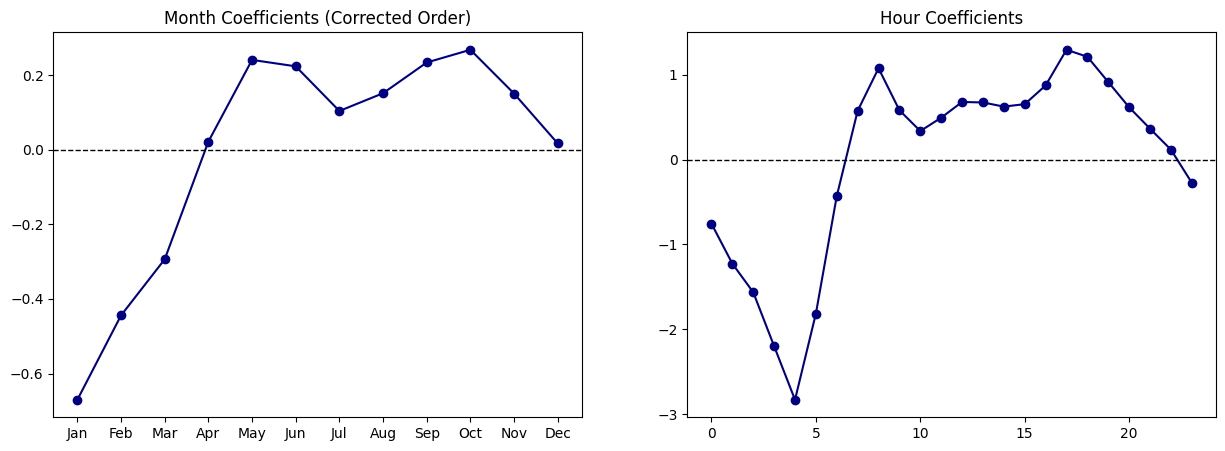

In [37]:
# 1. Grab parameters directly from your model object
# This assumes your model is named 'model'
params = model_poisson.params

# 2. Define the exact chronological order and their corresponding keys in your table
month_order = [
    'Jan', 'Feb', 'March', 'April', 'May', 'June', 
    'July', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec'
]

# 3. Build the list of coefficients
month_coefs = []
all_found_coefs = []

for m in month_order:
    key = f"C(mnth, Sum)[S.{m}]"
    if key in params:
        val = params[key]
        month_coefs.append(val)
        all_found_coefs.append(val)
    else:
        # If the month is missing (like Sept), put a placeholder
        month_coefs.append(None)

# 4. Calculate the missing value (September) 
# Sum coding requires all coefficients to sum to 0
missing_val = -sum(all_found_coefs)

# Fill the None (September) with the calculated value
month_coefs = [val if val is not None else missing_val for val in month_coefs]

# 5. Extract Hours (0-22 are in your table, 23 is missing)
hour_coefs = [params[f"C(hr, Sum)[S.{i}]"] for i in range(23)]
hour_coefs.append(-sum(hour_coefs)) # Add Hour 23

# 6. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Left Plot: Months (Using full names for the x-axis to be clear)
months_x = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ax1.plot(months_x, month_coefs, marker='o', color='navy', linestyle='-')
ax1.axhline(0, color='black', lw=1, ls='--')
ax1.set_title("Month Coefficients (Corrected Order)")

# Right Plot: Hours
ax2.plot(range(24), hour_coefs, marker='o', color='navy', linestyle='-')
ax2.axhline(0, color='black', lw=1, ls='--')
ax2.set_title("Hour Coefficients")

plt.show()

### Interpretation of Poisson Regression Results

#### 1. The "Percent Change" Secret
To understand the impact of a coefficient ($\beta$) in a Poisson model, we use the formula: $(e^{\beta} - 1) \times 100$.

* **Temperature (temp = 0.7853):** $e^{0.7853} \approx 2.19$.
    * **Interpretation:** For every 1-unit increase in normalized temperature, the number of bikers increases by **119%** (it more than doubles). This shows just how much more sensitive a Poisson model is to heat compared to the linear model.
* **Workingday (0.0147):** $e^{0.0147} \approx 1.015$.
    * **Interpretation:** Being a working day increases ridership by about **1.5%**. Notice that the p-value ($0.000$) now shows this is statistically significant, whereas it wasn't in the linear model!

#### 2. Weather Effects (Relative to Clear Skies)
Since "Clear Skies" is the baseline, these negative coefficients tell us exactly how much ridership "shrinks" when the weather turns.

| Weather Condition | Coefficient | Calculation ($e^{\beta}$) | Impact |
| :--- | :--- | :--- | :--- |
| **Cloudy/Misty** | -0.0752 | 0.927 | 7.3% decrease |
| **Light Rain/Snow** | -0.5758 | 0.562 | 43.8% decrease |
| **Heavy Rain/Snow** | -0.9263 | 0.396 | 60.4% decrease |

#### 3. Peak Hour Intensity (The "M" Shape)
The hour coefficients measure the "surge" relative to the daily average (due to Sum Coding).

* **Hour 17 (5 PM = 1.2946):** $e^{1.2946} \approx 3.65$.
    * At 5 PM, there are **3.65 times (265% more)** the average number of bikers.
* **Hour 4 (4 AM = -2.8305):** $e^{-2.8305} \approx 0.059$.
    * At 4 AM, ridership drops to only **5.9%** of the daily average.

#### 4. Important Model "Red Flags"
While the coefficients are intuitive, two numbers in the summary suggest the model isn't "perfect" yet:

* **Deviance (2.2804e+05):** In a perfectly fitted Poisson model, the Deviance should be roughly equal to the Degrees of Freedom (8605). Here, it is **26 times larger**.
* **Pearson chi2 (2.20e+05):** Like the deviance, this value is significantly higher than the degrees of freedom.

**Conclusion:** This indicates **Overdispersion**. The "noise" in the bike rentals is much higher than the Poisson distribution expects. While the coefficient estimates (the effect of temp, hour, etc.) are likely accurate, the p-values and standard errors might be "overconfident" (too small).

## Poisson Predictions

In [42]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import glm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Load Data
bikeshare = pd.read_csv('Bikeshare.csv')
bikeshare_filtered = bikeshare[bikeshare['weathersit'] != 'heavy rain/snow'].copy()

# 2. Split into Train (80%) and Test (20%)
# We use a random split here, but you could also split by the 'mnth' variable
train, test = train_test_split(bikeshare_filtered, test_size=0.2, random_state=42)

# 3. Fit the Poisson Model on the Training set
formula = 'bikers ~ workingday + temp + C(weathersit) + C(mnth, Sum) + C(hr, Sum)'
model_poisson = glm(formula, data=train, family=sm.families.Poisson()).fit()

# 4. Predict on the Test set
# The model returns the expected count (lambda) for each row
y_pred = model_poisson.predict(test)
y_true = test['bikers']

# 5. Evaluate Performance
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"Mean Absolute Error: {mae:.2f} bikers")
print(f"Root Mean Squared Error: {rmse:.2f} bikers")

Mean Absolute Error: 48.56 bikers
Root Mean Squared Error: 70.64 bikers


### Evaluating Model Performance: Is an MAE of 48 "Bad"?

#### 1. Relative vs. Absolute Error
Error metrics must be viewed in the context of the **mean of the target variable**. 
* **Mean Bikers:** ~191
* **MAE:** ~48.6
* **Percent Error:** $(48.6 / 191) \approx 25\%$
For a complex human-behavior dataset, a 25% average error indicates the model has captured the primary seasonal and hourly trends effectively.

#### 2. The RMSE/MAE Gap
The fact that RMSE (70.6) is much larger than MAE (48.6) indicates that the model's errors are not uniformly distributed. The model likely performs very well during "quiet" hours but struggles with the high variance of peak commute times.

#### 3. Identifying "Model Stress"
To improve this "bad" value, we would look at where the errors are largest. If the errors are concentrated in high-volume hours, the issue is likely **Overdispersion**—the Poisson model assumes the Variance = Mean, but in reality, the variance during rush hour is much higher. Moving to a **Negative Binomial** model would be the standard way to address this.